<a href="https://colab.research.google.com/github/Afila1996/RAE2822_Airfoil_Examples/blob/main/UNet_PINNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
from pathlib import Path
import os
import matplotlib.pyplot as plt


##Loading dataset

In [ ]:
data_dir = Path("/content/drive/MyDrive/RAE2822_data")

db_random = np.load(os.path.join(data_dir, "db_random.npy"), allow_pickle=True).item()
airfoil = np.load(os.path.join(data_dir, "airfoil.npy"))

## db_random

In [ ]:
print("Keys in db_random:")
for k in db_random.keys():
    print(f"{k}: {np.shape(db_random[k])}")

Keys in db_random:
idx: (1007,)
Alpha: (1007,)
Vinf: (1007,)
Cl: (1007,)
Cd: (1007,)
Cm: (1007,)
Cp: (1007, 691)
Cf: (1007, 691)
Xcoordinate: (1007, 27499)
Ycoordinate: (1007, 27499)
Pressure: (1007, 27499)
Mach: (1007, 27499)
Vmag: (1007, 27499)
Temperature: (1007, 27499)
Vx: (1007, 27499)
Vy: (1007, 27499)
Airfoil: (691, 2)


##Airfoil

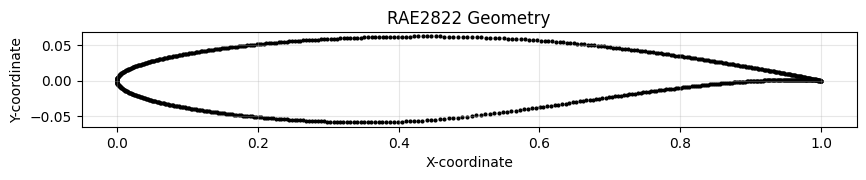

In [ ]:
plt.figure(figsize=(10, 4))
plt.scatter(airfoil[:, 0], airfoil[:, 1], s=4, c='black', label='Points')

plt.gca().set_aspect('equal', adjustable='box')
plt.title(f"RAE2822 Geometry")
plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.grid(True, alpha=0.3)
plt.show()

## Finding mach_inf

In [ ]:
def freestream_temperature(x, y, temperature, far_percentile=99):

    xc = np.median(x)
    yc = np.median(y)

    r = np.sqrt((x - xc)**2 + (y - yc)**2)

    r_threshold = np.percentile(r, far_percentile)
    far = r >= r_threshold

    T_inf = np.median(temperature[far])

    return T_inf


In [ ]:
gamma = 1.4
R = 287.0

N = len(db_random["idx"])

machinf = np.zeros(N)

i=0

for i in range(N):

    x = db_random["Xcoordinate"][i]
    y = db_random["Ycoordinate"][i]
    T = db_random["Temperature"][i]
    Vinf = db_random["Vinf"][i]


    T_inf = freestream_temperature(x, y, T)

    a_inf = np.sqrt(gamma * R * T_inf)

    machinf[i] = Vinf / a_inf


##Normalising geometry

In [ ]:
def normalize_geometry(x, y, machinf, M_ref):


    s = machinf/ M_ref


    x_lo = np.quantile(x, 0.01)


    y0 = np.median(y)

    # shift + Mach scaling
    x_scaled = (x - x_lo) * s
    y_scaled = (y - y0) * s

    x_le = np.quantile(x_scaled, 0.01)
    x_tr = np.quantile(x_scaled, 0.99)

    chord = x_tr - x_le


    xN = x_scaled / chord
    yN = y_scaled / chord

    return xN, yN


In [ ]:
# reference Mach
M_ref = np.mean(machinf)

xN_all = []
yN_all = []

i=0

for i in range(N):

    x = db_random["Xcoordinate"][i]
    y = db_random["Ycoordinate"][i]
    xN, yN = normalize_geometry(x, y, machinf[i], M_ref)

    xN_all.append(xN)
    yN_all.append(yN)


##Grid

In [ ]:
xmin, xmax = -0.3, 1.3
ymin, ymax = -0.6, 0.6


Nx, Ny = 128, 128


x_lin = np.linspace(xmin, xmax, Nx)
y_lin = np.linspace(ymin, ymax, Ny)

Xg, Yg = np.meshgrid(x_lin, y_lin)


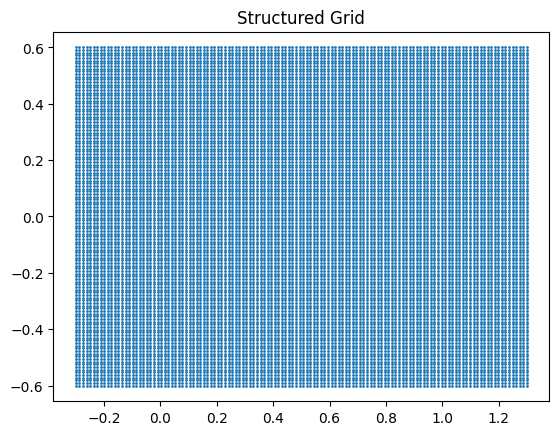

In [ ]:
plt.scatter(Xg, Yg, s=1)
plt.axis('equal')
plt.title("Structured Grid")
plt.show()


##Interpolation

In [ ]:
from scipy.interpolate import griddata


def interpolate_to_grid(x, y, values, Xg, Yg, method='cubic'):

    pts = np.column_stack([x, y])

    Z = griddata(pts, values, (Xg, Yg), method=method)

    # fill holes
    if np.isnan(Z).any():
        Z_nn = griddata(pts, values, (Xg, Yg), method='nearest')
        Z = np.where(np.isnan(Z), Z_nn, Z)

    return Z.astype(np.float32)


In [ ]:
from matplotlib.path import Path
def airfoil_mask(Airfoil, Xg, Yg):


    airfoil_path = Path(airfoil)


    grid_points = np.column_stack((Xg.ravel(), Yg.ravel()))


    inside = airfoil_path.contains_points(grid_points)

    mask = inside.reshape(Xg.shape)

    return mask.astype(np.float32)


airfoil_mask = airfoil_mask(airfoil, Xg, Yg)

In [ ]:
def interpolation(xN, yN, u, v, p, mach_inf, aoa, airfoil_mask, Xg, Yg):

    # interpolate outputs
    u_g = interpolate_to_grid(xN, yN, u, Xg, Yg)
    v_g = interpolate_to_grid(xN, yN, v, Xg, Yg)
    p_g = interpolate_to_grid(xN, yN, p, Xg, Yg)


    airfoil_mask_binary = airfoil_mask.astype(bool)
    p_g[airfoil_mask_binary] = 0.0
    u_g[airfoil_mask_binary] = 0.0
    v_g[airfoil_mask_binary] = 0.0

    #coordinate channels
    xmin, xmax = Xg.min(), Xg.max()
    ymin, ymax = Yg.min(), Yg.max()

    xchan = 2*(Xg-xmin)/(xmax-xmin)-1
    ychan = 2*(Yg-ymin)/(ymax-ymin)-1


    mach_chan = np.full_like(xchan, mach_inf)
    aoa_chan = np.full_like(xchan, aoa)

    #build input tensor
    X_in = np.stack([xchan, ychan, airfoil_mask, mach_chan, aoa_chan], axis=0)

    # build output tensor
    Y_out = np.stack([p_g, u_g, v_g], axis=0)

    return X_in.astype(np.float32), Y_out.astype(np.float32)


In [ ]:
dataset_inputs = []
dataset_outputs = []

for i in range(N):

    xN = xN_all[i]
    yN = yN_all[i]

    u = db_random["Vx"][i]
    v = db_random["Vy"][i]
    p = db_random["Pressure"][i]


    mach_inf = machinf[i]
    aoa = db_random["Alpha"][i]

    X_in, Y_out = interpolation(xN, yN, u, v, p, mach_inf, aoa, airfoil_mask, Xg, Yg)

    dataset_inputs.append(X_in)
    dataset_outputs.append(Y_out)


In [ ]:
import pickle



# dataset_inputs  = np.stack(dataset_inputs)   # (1007, 5, 128, 128)
# dataset_outputs = np.stack(dataset_outputs)  # (1007, 3, 128, 128)

# print(f"Inputs shape:  {dataset_inputs.shape}")
# print(f"Outputs shape: {dataset_outputs.shape}")


# folder_path = "/content/drive/MyDrive/RAE2822_data"
# os.makedirs(folder_path, exist_ok=True)

# # Save
# save_path = os.path.join(folder_path, "dataset.pkl")

# with open(save_path, 'wb') as f:
#     pickle.dump({
#         'dataset_inputs'  : dataset_inputs,
#         'dataset_outputs' : dataset_outputs
#     }, f)




In [ ]:
import pickle

load_path = "/content/drive/MyDrive/RAE2822_data/dataset.pkl"

with open(load_path, 'rb') as f:
    data = pickle.load(f)

dataset_inputs  = data['dataset_inputs']
dataset_outputs = data['dataset_outputs']

print(f"Loaded successfully!")
print(f"Inputs shape:  {dataset_inputs.shape}")   # (1007, 5, 128, 128)
print(f"Outputs shape: {dataset_outputs.shape}")  # (1007, 3, 128, 128)

Loaded successfully!
Inputs shape:  (1007, 5, 128, 128)
Outputs shape: (1007, 3, 128, 128)


## Normalisation

In [ ]:
mach_mean = dataset_inputs[:, 3].mean()
mach_std = dataset_inputs[:, 3].std()
dataset_inputs[:, 3, :, :] = (dataset_inputs[:, 3, :, :] - mach_mean) / (mach_std + 1e-8)

aoa_mean = dataset_inputs[:, 4].mean()
aoa_std = dataset_inputs[:, 4].std()
dataset_inputs[:, 4, :, :] = (dataset_inputs[:, 4, :, :] - aoa_mean) / (aoa_std + 1e-8)



mask = dataset_inputs[0, 2, :, :]
valid_region = (mask == 0)

norm_stats = {}

for ch in range(3):
    channel_name = ['Pressure', 'U-velocity', 'V-velocity'][ch]
    channel_data = dataset_outputs[:, ch, :, :]

    valid_values = channel_data[:, valid_region]

    mean = valid_values.mean()
    std  = valid_values.std()


    norm_stats[channel_name] = {
        'mean': float(mean),
        'std' : float(std)
    }

    dataset_outputs[:, ch, :, :] = (channel_data - mean) / (std + 1e-8)

    for i in range(len(dataset_outputs)):
        dataset_outputs[i, ch][mask == 1] = 0.0

physics_norm_stats = {
    'p_mean': norm_stats['Pressure']['mean'],
    'p_std' : norm_stats['Pressure']['std'],
    'u_mean': norm_stats['U-velocity']['mean'],
    'u_std' : norm_stats['U-velocity']['std'],
    'v_mean': norm_stats['V-velocity']['mean'],
    'v_std' : norm_stats['V-velocity']['std']
}

## Data Loader

In [ ]:
import os
import pandas as pd
from torchvision.io import decode_image

In [ ]:
from sklearn.model_selection import train_test_split


X_tv, X_test, y_tv, y_test = train_test_split(dataset_inputs, dataset_outputs, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=0.2, random_state=42)

print(f"Train set: {X_train.shape[0]}")
print(f"Validation set: {X_val.shape[0]}")
print(f"Test set: {X_test.shape[0]}")

Train set: 644
Validation set: 161
Test set: 202


In [ ]:
import torch
from torch.utils.data import Dataset

class CFDDataset(Dataset):
    def __init__(self, inputs, outputs):
        self.inputs = torch.FloatTensor(inputs)
        self.outputs = torch.FloatTensor(outputs)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.outputs[idx]

In [ ]:
train_dataset = CFDDataset(X_train, y_train)
val_dataset = CFDDataset(X_val, y_val)
test_dataset = CFDDataset(X_test, y_test)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)

val_loader = DataLoader(val_dataset, batch_size=16, shuffle=True, num_workers=2)

test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 41
Validation batches: 11
Test batches: 13


##U-Net

In [ ]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),nn.BatchNorm2d(out_channels),
                                  nn.ReLU(inplace=True), nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                                  nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True))

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=5, out_channels=3, features=[64, 128, 256, 512]):
        super(UNet, self).__init__()

        self.encoder1 = DoubleConv(in_channels, features[0])
        self.encoder2 = DoubleConv(features[0], features[1])
        self.encoder3 = DoubleConv(features[1], features[2])
        self.encoder4 = DoubleConv(features[2], features[3])


        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)


        self.bottleneck = DoubleConv(features[3], features[3]*2)


        self.upconv4 = nn.ConvTranspose2d(features[3]*2, features[3],
                                          kernel_size=2, stride=2)
        self.decoder4 = DoubleConv(features[3]*2, features[3])

        self.upconv3 = nn.ConvTranspose2d(features[3], features[2],
                                          kernel_size=2, stride=2)
        self.decoder3 = DoubleConv(features[2]*2, features[2])

        self.upconv2 = nn.ConvTranspose2d(features[2], features[1],
                                          kernel_size=2, stride=2)
        self.decoder2 = DoubleConv(features[1]*2, features[1])

        self.upconv1 = nn.ConvTranspose2d(features[1], features[0],
                                          kernel_size=2, stride=2)
        self.decoder1 = DoubleConv(features[0]*2, features[0])


        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)


    def forward(self, x):

        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool(enc1))
        enc3 = self.encoder3(self.pool(enc2))
        enc4 = self.encoder4(self.pool(enc3))


        bottleneck = self.bottleneck(self.pool(enc4))


        dec4 = self.upconv4(bottleneck)
        dec4 = torch.cat([dec4, enc4], dim=1)
        dec4 = self.decoder4(dec4)

        dec3 = self.upconv3(dec4)
        dec3 = torch.cat([dec3, enc3], dim=1)
        dec3 = self.decoder3(dec3)

        dec2 = self.upconv2(dec3)
        dec2 = torch.cat([dec2, enc2], dim=1)
        dec2 = self.decoder2(dec2)

        dec1 = self.upconv1(dec2)
        dec1 = torch.cat([dec1, enc1], dim=1)
        dec1 = self.decoder1(dec1)


        output = self.final_conv(dec1)

        return output

##Training

##Physics loss

In [ ]:
class EulerLoss(nn.Module):
    def __init__(self, xmin, xmax, ymin, ymax, Nx, Ny, w_continuity=1.0,
                 w_momentum_x=0.5, w_momentum_y=0.5, **kwargs):
        super(EulerLoss, self).__init__()

        self.dx           = (xmax - xmin) / (Nx - 1)
        self.dy           = (ymax - ymin) / (Ny - 1)
        self.w_continuity = w_continuity
        self.w_momentum_x = w_momentum_x
        self.w_momentum_y = w_momentum_y

    def central_diff_x(self, field):
        padded = torch.nn.functional.pad(field, (1,1,0,0), mode='replicate')
        return (padded[:,:,:,2:] - padded[:,:,:,:-2]) / (2.0 * self.dx)

    def central_diff_y(self, field):
        padded = torch.nn.functional.pad(field, (0,0,1,1), mode='replicate')
        return (padded[:,:,2:,:] - padded[:,:,:-2,:]) / (2.0 * self.dy)

    def forward(self, predictions, inputs):

        mask         = inputs[:, 2:3, :, :]
        valid_region = (mask == 0).float()


        p = predictions[:, 0:1] * valid_region
        u = predictions[:, 1:2] * valid_region
        v = predictions[:, 2:3] * valid_region


        continuity = (self.central_diff_x(u) + self.central_diff_y(v)) * valid_region


        momentum_x = (u * self.central_diff_x(u) + v * self.central_diff_y(u) + self.central_diff_x(p)) * valid_region


        momentum_y = (u * self.central_diff_x(v) + v * self.central_diff_y(v) + self.central_diff_y(p)) * valid_region


        num_valid = valid_region.sum(dim=[2,3], keepdim=True) + 1e-8

        loss = ((self.w_continuity * continuity**2 + self.w_momentum_x * momentum_x**2 +
                 self.w_momentum_y * momentum_y**2) / num_valid).mean()

        return loss

##Total loss

In [ ]:
class CombinedLoss(nn.Module):
    def __init__(self, physics_weight, u_mean, u_std, v_mean, v_std, p_mean, p_std):
        super(CombinedLoss, self).__init__()

        self.data_loss_fn    = MaskedMSELoss()
        self.physics_loss_fn = EulerLoss(xmin=-0.3, xmax=1.3, ymin=-0.6, ymax=0.6, Nx=128, Ny=128, w_continuity = 1.0,
                                         w_momentum_x = 0.5, w_momentum_y = 0.5, gamma=1.4, u_mean=u_mean, u_std=u_std,
                                         v_mean=v_mean, v_std=v_std, p_mean=p_mean, p_std=p_std)
        self.physics_weight     = physics_weight
        self.current_epoch      = 0

    def set_epoch(self, epoch):

        self.current_epoch = epoch

    def get_current_weight(self):
        warmup_epochs = 20
        if self.current_epoch < warmup_epochs:
            return self.physics_weight * (self.current_epoch / warmup_epochs)
        return self.physics_weight

    def forward(self, predictions, targets, inputs):
        data_loss    = self.data_loss_fn(predictions, targets, inputs)
        physics_loss = self.physics_loss_fn(predictions, inputs)

        weight     = self.get_current_weight()
        total_loss = data_loss + weight * physics_loss

        return total_loss, data_loss, physics_loss

In [ ]:
def apply_mask(predictions, inputs):
    mask     = inputs[:, 2:3, :, :]
    mask_3ch = mask.expand(-1, 3, -1, -1)
    return predictions * (1 - mask_3ch)

def r2_score(predictions, targets, inputs):

    mask         = inputs[0, 2, :, :]
    valid_region = (mask == 0)

    channel_names = ['Pressure', 'U-velocity', 'V-velocity']
    r2_scores = {}

    for ch in range(3):
        pred_valid = predictions[:, ch, :, :][:, valid_region].flatten()
        true_valid = targets[:,    ch, :, :][:, valid_region].flatten()

        ss_res = np.sum((true_valid - pred_valid) ** 2)
        ss_tot = np.sum((true_valid - np.mean(true_valid)) ** 2)

        r2_scores[channel_names[ch]] = 1 - (ss_res / (ss_tot + 1e-8))

    return r2_scores

In [ ]:
import torch.optim as optim
import time
from torch.optim.lr_scheduler import CosineAnnealingLR


class MaskedMSELoss(nn.Module):
    def __init__(self):
        super(MaskedMSELoss, self).__init__()

    def forward(self, predictions, targets, inputs):
        mask = inputs[:, 2:3, :, :]
        valid_region = (mask == 0).float()
        squared_error = (predictions - targets) ** 2
        masked_error = squared_error * valid_region
        num_valid = valid_region.sum() * 3

        if num_valid > 0:
            loss = masked_error.sum() / num_valid
        else:
            loss = masked_error.sum()

        return loss

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    epoch_loss = 0.0
    num_batches = len(dataloader)

    for batch_idx, (inputs, targets) in enumerate(dataloader):
        inputs = inputs.to(device)
        targets = targets.to(device)


        inputs[:, 0:1, :, :].requires_grad_(True)
        inputs[:, 1:2, :, :].requires_grad_(True)

        predictions = model(inputs)

        predictions = apply_mask(predictions, inputs)


        total_loss, data_loss, physics_loss = criterion(predictions, targets, inputs)

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        epoch_loss += total_loss.item()

        if batch_idx % 10 == 0:
            print(f'  Batch [{batch_idx}/{num_batches}] ' f'Total: {total_loss.item():.6f} | ' f'Data: {data_loss.item():.6f} | '
                  f'Physics: {physics_loss.item():.6f}')

    return epoch_loss / num_batches



def validate(model, dataloader, criterion, device):
    model.eval()
    epoch_loss = 0.0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            targets = targets.to(device)


            inputs[:, 0:1, :, :].requires_grad_(True)
            inputs[:, 1:2, :, :].requires_grad_(True)

            predictions = model(inputs)

            predictions = apply_mask(predictions, inputs)


            total_loss, data_loss, physics_loss = criterion(predictions, targets, inputs)

            epoch_loss += total_loss.item()
            all_predictions.append(predictions.cpu())
            all_targets.append(targets.cpu())

    all_predictions = torch.cat(all_predictions, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    return epoch_loss / len(dataloader), all_predictions, all_targets




def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, num_epochs=50, save_path='best_model.pth'):

    train_losses  = []
    val_losses    = []
    best_val_loss = float('inf')
    start_time    = time.time()

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")


        criterion.set_epoch(epoch)
        current_weight = criterion.get_current_weight()

        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_preds, val_targets = validate(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        scheduler.step()


        print(f"Train Loss:     {train_loss:.6f}")
        print(f"Val Loss:       {val_loss:.6f}")
        # print(f"Physics Weight: {current_weight:.6f}")


        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({'epoch'               : epoch + 1, 'model_state_dict'    : model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(), 'train_loss'          : train_loss,
                        'val_loss'            : val_loss}, save_path)


    print(f"Time: {(time.time()-start_time)/60:.2f} minutes")
    print(f"Best Val Loss: {best_val_loss:.6f}")

    return train_losses, val_losses




def evaluate_model(model, test_loader, criterion, device):
    model.eval()
    test_loss       = 0.0
    all_predictions = []
    all_targets     = []
    all_inputs      = []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs  = inputs.to(device)
            targets = targets.to(device)

            predictions = model(inputs)
            predictions = apply_mask(predictions, inputs)

            total_loss, data_loss, physics_loss = criterion(predictions, targets, inputs)

            test_loss += total_loss.item()
            all_predictions.append(predictions.cpu())
            all_targets.append(targets.cpu())
            all_inputs.append(inputs.cpu())

    all_predictions = torch.cat(all_predictions, dim=0).numpy()
    all_targets     = torch.cat(all_targets,     dim=0).numpy()
    all_inputs      = torch.cat(all_inputs,      dim=0).numpy()
    test_loss       = test_loss / len(test_loader)

    r2 = r2_score(all_predictions, all_targets, all_inputs)




    print(f"  Test Loss : {test_loss:.6f}")
    print()
    print("  R² Scores:")
    for ch, val in r2.items():
        print(f"    {ch:12s}: {val:.6f}")


    return all_predictions, all_targets, test_loss, r2







def plot_training_curves(train_losses, val_losses, save_path='training_curves.png'):

    plt.figure(figsize=(10, 6))

    epochs = range(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, 'b-', label='Train Loss', linewidth=2)
    plt.plot(epochs, val_losses, 'r-', label='Val Loss', linewidth=2)

    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss (MSE)', fontsize=12)
    plt.title('Training Progress', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()


def visualize_prediction(idx, predictions, targets, save_path=None):

    pred = predictions[idx]
    true = targets[idx]
    error = np.abs(pred - true)

    channel_names = ['Pressure', 'U-velocity', 'V-velocity']

    fig, axes = plt.subplots(3, 3, figsize=(14, 10))

    for i in range(3):

        im0 = axes[i, 0].imshow(true[i], cmap='RdBu_r', aspect='auto')
        axes[i, 0].set_title(f'{channel_names[i]} - Truth', fontsize=10)
        axes[i, 0].axis('off')
        plt.colorbar(im0, ax=axes[i, 0], fraction=0.046)


        im1 = axes[i, 1].imshow(pred[i], cmap='RdBu_r', aspect='auto')
        axes[i, 1].set_title(f'{channel_names[i]} - Prediction', fontsize=10)
        axes[i, 1].axis('off')
        plt.colorbar(im1, ax=axes[i, 1], fraction=0.046)


        im2 = axes[i, 2].imshow(error[i], cmap='hot', aspect='auto')
        axes[i, 2].set_title(f'{channel_names[i]} - Error', fontsize=10)
        axes[i, 2].axis('off')
        plt.colorbar(im2, ax=axes[i, 2], fraction=0.046)

    plt.suptitle(f'Sample {idx} - Prediction Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')


    plt.show()






def run_pipeline(model, train_loader, val_loader, test_loader, device, norm_stats):

    criterion = CombinedLoss(physics_weight = 0.01, u_mean = norm_stats['u_mean'], u_std  = norm_stats['u_std'],
                             v_mean = norm_stats['v_mean'], v_std  = norm_stats['v_std'], p_mean = norm_stats['p_mean'],
                             p_std  = norm_stats['p_std'])

    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)



    scheduler = CosineAnnealingLR(optimizer, T_max  =50, eta_min = 1e-7)


    train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device,
                                           num_epochs=50, save_path='best_model.pth')

    plot_training_curves(train_losses, val_losses)

    checkpoint = torch.load('best_model.pth')
    model.load_state_dict(checkpoint['model_state_dict'])

    predictions, targets, test_loss, r2 = evaluate_model( model, test_loader, criterion, device)

    visualize_prediction(10, predictions, targets, save_path='sample_1')








Epoch 1/50
  Batch [0/41] Total: 1.351373 | Data: 1.351373 | Physics: 0.017081
  Batch [10/41] Total: 0.249009 | Data: 0.249009 | Physics: 0.008432
  Batch [20/41] Total: 0.206052 | Data: 0.206052 | Physics: 0.008953
  Batch [30/41] Total: 0.344976 | Data: 0.344976 | Physics: 0.007671
  Batch [40/41] Total: 0.444731 | Data: 0.444731 | Physics: 0.018120
Train Loss:     0.311177
Val Loss:       0.182816

Epoch 2/50
  Batch [0/41] Total: 0.150502 | Data: 0.150496 | Physics: 0.011051
  Batch [10/41] Total: 0.095386 | Data: 0.095380 | Physics: 0.011868
  Batch [20/41] Total: 0.083148 | Data: 0.083144 | Physics: 0.008551
  Batch [30/41] Total: 0.225936 | Data: 0.225930 | Physics: 0.011784
  Batch [40/41] Total: 0.396613 | Data: 0.396607 | Physics: 0.011406
Train Loss:     0.176173
Val Loss:       0.119398

Epoch 3/50
  Batch [0/41] Total: 0.136355 | Data: 0.136342 | Physics: 0.013001
  Batch [10/41] Total: 0.087434 | Data: 0.087422 | Physics: 0.012140
  Batch [20/41] Total: 0.140677 | Data:

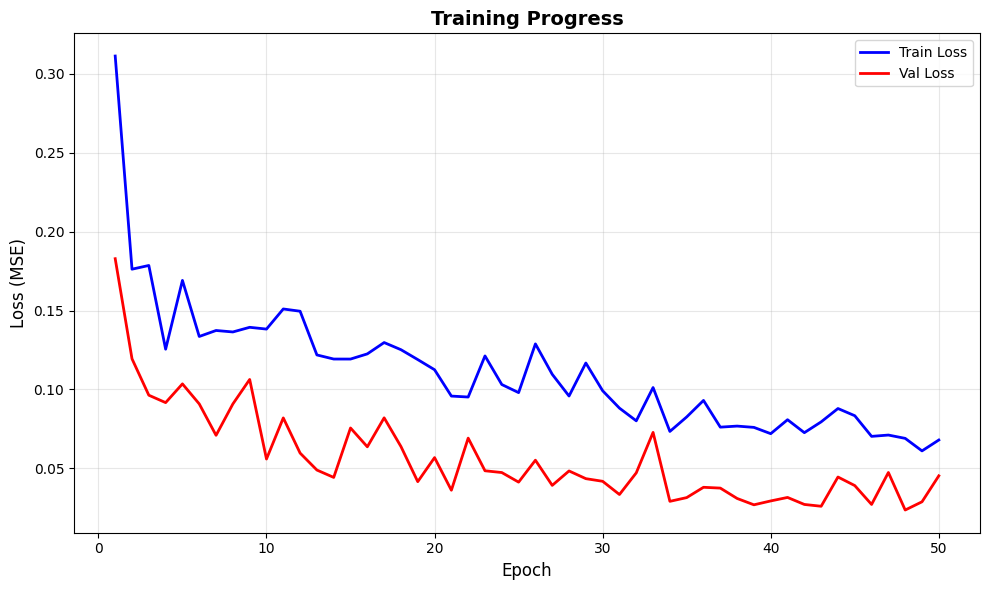

  Test Loss : 0.030234

  R² Scores:
    Pressure    : 0.948841
    U-velocity  : 0.973926
    V-velocity  : 0.992028


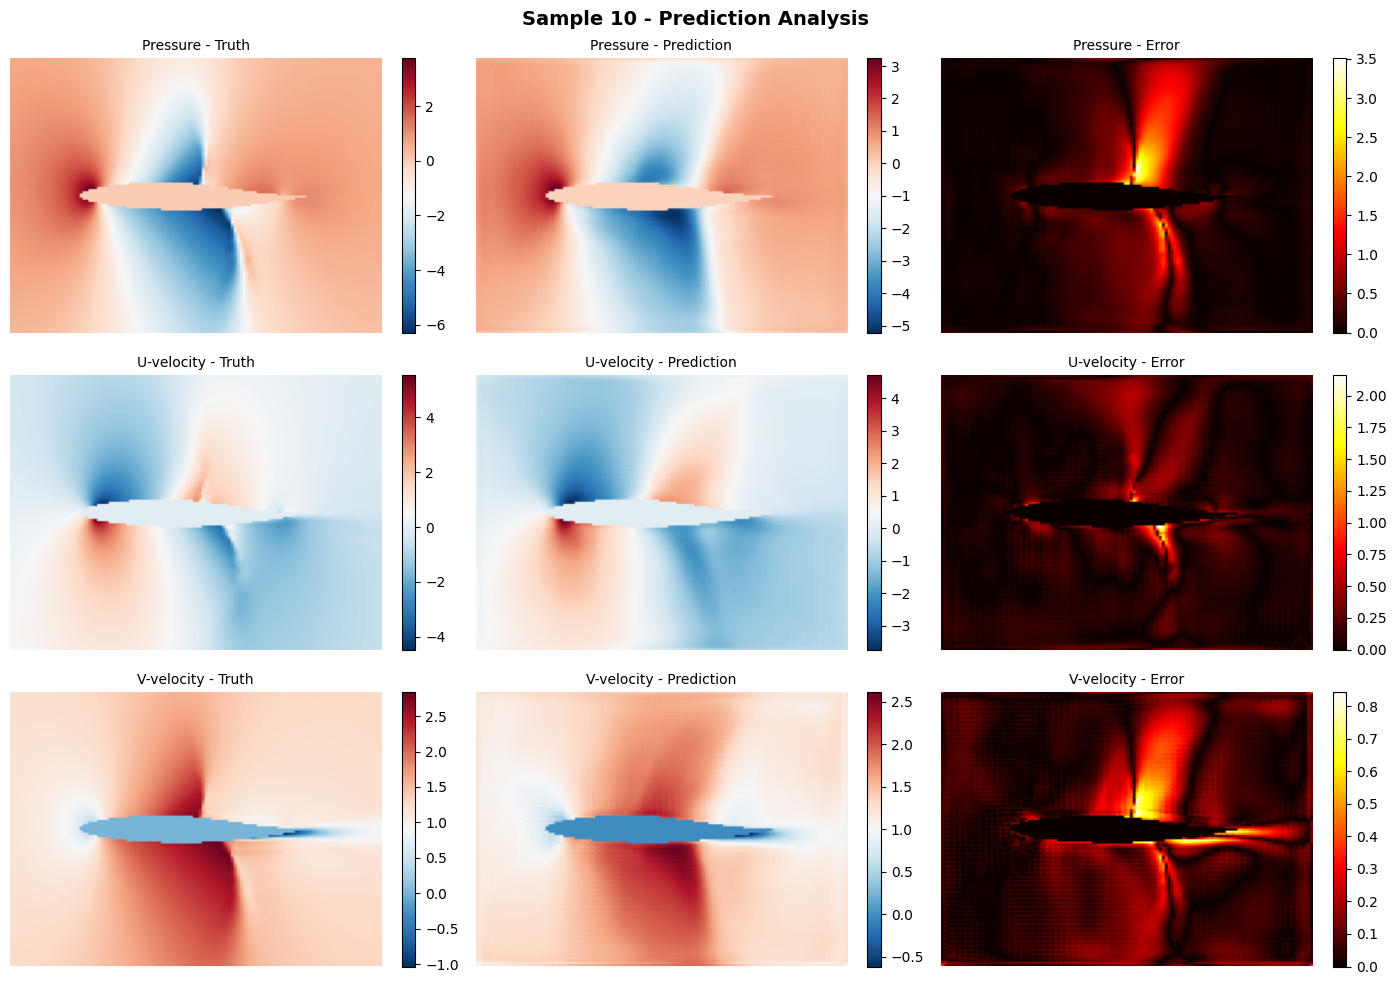

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels=5, out_channels=3).to(device)




run_pipeline(model, train_loader, val_loader, test_loader, device, norm_stats=physics_norm_stats)